In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
riders = pd.read_excel('/Users/olabodetaiwo/Documents/ridewise project/riders.xlsx')
drivers = pd.read_excel('/Users/olabodetaiwo/Documents/ridewise project/drivers.xlsx')
promotions = pd.read_excel('/Users/olabodetaiwo/Documents/ridewise project/promotions.xlsx')
sessions = pd.read_excel('/Users/olabodetaiwo/Documents/ridewise project/sessions.xlsx')
trips = pd.read_excel('/Users/olabodetaiwo/Documents/ridewise project/trips.xlsx')

In [3]:
trips = pd.read_excel('/Users/olabodetaiwo/Documents/ridewise project/trips.xlsx')
trips

,trip_id,rider_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather,city,loyalty_status
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 18:41:50+02:27,2024-11-27 19:33:50+02:27,-1.108123,36.912209,-1.068155,36.875377,Foggy,Nairobi,Bronze
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 23:13:48+00:14,2024-10-28 23:26:48+00:14,6.675266,3.515740,6.641734,3.525620,Sunny,Lagos,Gold
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 05:36:41+02:27,2025-02-17 05:52:41+02:27,-1.248589,37.010668,-1.273182,37.018586,Cloudy,Nairobi,Bronze
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 19:27:14+02:05,2024-06-18 19:32:14+02:05,29.819554,31.188780,29.837689,31.232978,Cloudy,Cairo,Bronze
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 09:58:16+02:27,2024-10-05 10:28:16+02:27,-1.676479,36.729219,-1.638395,36.694063,Sunny,Nairobi,Gold
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,T199995,R08022,D04562,26.79,1.3,0.00,Card,2025-03-14 18:16:26+00:14,2025-03-14 18:27:26+00:14,6.511389,3.297189,6.545565,3.327685,Cloudy,Lagos,Silver
199996,T199996,R05421,D03984,14.65,1.0,0.00,Card,2024-07-02 06:59:36+00:14,2024-07-02 07:36:36+00:14,6.489143,3.492786,6.453581,3.514289,Sunny,Lagos,Bronze
199997,T199997,R06619,D01173,12.87,1.2,0.00,Mobile Money,2024-05-06 20:38:57+00:14,2024-05-06 21:25:57+00:14,6.459348,3.527623,6.451930,3.521616,Rainy,Lagos,Bronze
199998,T199998,R02867,D00974,17.18,1.3,0.00,Mobile Money,2024-09-25 03:11:33+00:14,2024-09-25 03:45:33+00:14,6.540074,3.471683,6.540339,3.426481,Rainy,Lagos,Gold


In [4]:
ridewise = (
    trips
        .merge(drivers, how='left', on='driver_id', suffixes=("","_drivers"))
        .merge(riders, how='left', on='rider_id',suffixes=("","_riders"))
        .merge(sessions, how='left', on='rider_id', suffixes=("","_sessions"))
        .merge(promotions, how = 'left', on = 'city', suffixes=("","_promotions"))
)

In [5]:
ridewise.head()

,trip_id,rider_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,...,promo_id,promo_name,promo_type,promo_value,start_date,end_date,target_segment,ab_test_groups,test_allocation,success_metric
0,T000000,R05207,D00315,12.11,1.0,0.0,Card,2024-11-27 18:41:50+02:27,2024-11-27 19:33:50+02:27,-1.108123,...,P000,Peak Hour Pass,surge_waiver,1.0,45773,45802,All,['All'],[1.0],Usage Frequency
1,T000000,R05207,D00315,12.11,1.0,0.0,Card,2024-11-27 18:41:50+02:27,2024-11-27 19:33:50+02:27,-1.108123,...,P003,Loyalty Bonus,points,100.0,45773,45781,Gold+,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",Conversion Rate
2,T000000,R05207,D00315,12.11,1.0,0.0,Card,2024-11-27 18:41:50+02:27,2024-11-27 19:33:50+02:27,-1.108123,...,P004,Loyalty Bonus,points,100.0,45773,45792,Gold+,['All'],[1.0],Usage Frequency
3,T000000,R05207,D00315,12.11,1.0,0.0,Card,2024-11-27 18:41:50+02:27,2024-11-27 19:33:50+02:27,-1.108123,...,P005,Loyalty Bonus,points,100.0,45773,45793,Gold+,['All'],[1.0],Usage Frequency
4,T000000,R05207,D00315,12.11,1.0,0.0,Card,2024-11-27 18:41:50+02:27,2024-11-27 19:33:50+02:27,-1.108123,...,P007,First Ride Discount,discount,0.3,45773,45803,New,['All'],[1.0],ROI


In [6]:
ridewise.columns

Index(['trip_id', 'rider_id', 'driver_id', 'fare', 'surge_multiplier', 'tip',
       'payment_type', 'pickup_time', 'dropoff_time', 'pickup_lat',
       'pickup_lng', 'dropoff_lat', 'dropoff_lng', 'weather', 'city',
       'loyalty_status', 'rating', 'vehicle_type', 'signup_date',
       'last_active', 'city_drivers', 'acceptance_rate', 'signup_date_riders',
       'loyalty_status_riders', 'age', 'city_riders', 'avg_rating_given',
       'churn_prob', 'referred_by', 'session_id', 'session_time',
       'time_on_app', 'pages_visited', 'converted', 'city_sessions',
       'loyalty_status_sessions', 'promo_id', 'promo_name', 'promo_type',
       'promo_value', 'start_date', 'end_date', 'target_segment',
       'ab_test_groups', 'test_allocation', 'success_metric'],
      dtype='object')

In [7]:
ridewise.tail()

,trip_id,rider_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,...,promo_id,promo_name,promo_type,promo_value,start_date,end_date,target_segment,ab_test_groups,test_allocation,success_metric
5000333,T199999,R07749,D04894,13.47,1.0,0.0,Card,2024-05-24 18:19:39+02:05,2024-05-24 18:51:39+02:05,30.234277,...,P018,First Ride Discount,discount,0.3,45773,45790,New,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",ROI
5000334,T199999,R07749,D04894,13.47,1.0,0.0,Card,2024-05-24 18:19:39+02:05,2024-05-24 18:51:39+02:05,30.234277,...,P001,Peak Hour Pass,surge_waiver,1.0,45773,45799,All,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",Conversion Rate
5000335,T199999,R07749,D04894,13.47,1.0,0.0,Card,2024-05-24 18:19:39+02:05,2024-05-24 18:51:39+02:05,30.234277,...,P002,Peak Hour Pass,surge_waiver,1.0,45773,45793,All,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",ROI
5000336,T199999,R07749,D04894,13.47,1.0,0.0,Card,2024-05-24 18:19:39+02:05,2024-05-24 18:51:39+02:05,30.234277,...,P009,Referral Special,credit,15.0,45773,45795,Active,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",ROI
5000337,T199999,R07749,D04894,13.47,1.0,0.0,Card,2024-05-24 18:19:39+02:05,2024-05-24 18:51:39+02:05,30.234277,...,P018,First Ride Discount,discount,0.3,45773,45790,New,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",ROI


In [8]:
ridewise.isnull().sum()

trip_id                          0
rider_id                         0
driver_id                        0
fare                             0
surge_multiplier                 0
tip                              0
payment_type                     0
pickup_time                      0
dropoff_time                     0
pickup_lat                       0
pickup_lng                       0
dropoff_lat                      0
dropoff_lng                      0
weather                          0
city                             0
loyalty_status                   0
rating                           0
vehicle_type                     0
signup_date                      0
last_active                      0
city_drivers                     0
acceptance_rate                  0
signup_date_riders               0
loyalty_status_riders            0
age                              0
city_riders                      0
avg_rating_given                 0
churn_prob                       0
referred_by         

In [9]:
ridewise.dropna(inplace = True)


In [10]:
ridewise.isnull().sum()

trip_id                    0
rider_id                   0
driver_id                  0
fare                       0
surge_multiplier           0
tip                        0
payment_type               0
pickup_time                0
dropoff_time               0
pickup_lat                 0
pickup_lng                 0
dropoff_lat                0
dropoff_lng                0
weather                    0
city                       0
loyalty_status             0
rating                     0
vehicle_type               0
signup_date                0
last_active                0
city_drivers               0
acceptance_rate            0
signup_date_riders         0
loyalty_status_riders      0
age                        0
city_riders                0
avg_rating_given           0
churn_prob                 0
referred_by                0
session_id                 0
session_time               0
time_on_app                0
pages_visited              0
converted                  0
city_sessions 

In [11]:
ridewise.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1513782 entries, 24 to 5000337
Data columns (total 46 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   trip_id                  1513782 non-null  object        
 1   rider_id                 1513782 non-null  object        
 2   driver_id                1513782 non-null  object        
 3   fare                     1513782 non-null  float64       
 4   surge_multiplier         1513782 non-null  float64       
 5   tip                      1513782 non-null  float64       
 6   payment_type             1513782 non-null  object        
 7   pickup_time              1513782 non-null  object        
 8   dropoff_time             1513782 non-null  object        
 9   pickup_lat               1513782 non-null  float64       
 10  pickup_lng               1513782 non-null  float64       
 11  dropoff_lat              1513782 non-null  float64       
 12  drop

In [12]:
ridewise["pickup_time"] = pd.to_datetime(ridewise["pickup_time"], utc=True, errors='coerce')
ridewise["dropoff_time"] = pd.to_datetime(ridewise["dropoff_time"], utc=True, errors='coerce')
ridewise["signup_date"] = pd.to_datetime(ridewise["signup_date"], utc=True, errors='coerce')
ridewise["signup_date_riders"] = pd.to_datetime(ridewise["signup_date_riders"], utc=True, errors='coerce')


In [13]:
#cols = [
   # "pickup_time",
    #"dropoff_time",
   # "signup_date",
    #"signup_date_sessions",
   # "signup_date_riders"
#]

#ridewise[cols] = ridewise[cols].apply(
 #   lambda x: pd.to_datetime(x, utc=True, errors='coerce')
#)


In [14]:
ridewise.describe()

,fare,surge_multiplier,tip,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,rating,last_active,acceptance_rate,age,avg_rating_given,churn_prob,time_on_app,pages_visited,converted,promo_value,start_date,end_date
count,1.513782e+06,1.513782e+06,1.513782e+06,1.513782e+06,1.513782e+06,1.513782e+06,1.513782e+06,1.513782e+06,1513782,1.513782e+06,1.513782e+06,1.513782e+06,1.513782e+06,1.513782e+06,1.513782e+06,1.513782e+06,1.513782e+06,1513782.0,1.513782e+06
mean,1.540145e+01,1.141182e+00,4.637765e-01,9.621730e+00,2.419404e+01,9.621719e+00,2.419428e+01,4.174152e+00,2025-03-08 06:04:45.090283520,6.939875e-01,3.491956e+01,4.458106e+00,2.867868e-01,9.694789e+01,2.755611e+00,1.551095e-01,2.813017e+01,45773.0,4.579194e+04
min,3.500000e+00,1.000000e+00,0.000000e+00,-1.786360e+00,2.879417e+00,-1.831403e+00,2.830979e+00,3.100000e+00,2022-04-28 16:45:23.766000,1.000000e-01,1.800000e+01,2.900000e+00,2.933968e-03,0.000000e+00,1.000000e+00,0.000000e+00,3.000000e-01,45773.0,4.578100e+04
25%,1.099000e+01,1.000000e+00,0.000000e+00,-1.228956e+00,3.490873e+00,-1.228944e+00,3.491705e+00,3.700000e+00,2025-03-13 03:51:01.369999872,5.641036e-01,2.814166e+01,4.200000e+00,1.612078e-01,1.200000e+01,1.000000e+00,0.000000e+00,3.000000e-01,45773.0,4.578300e+04
50%,1.410000e+01,1.000000e+00,0.000000e+00,6.429799e+00,3.129264e+01,6.429100e+00,3.129253e+01,4.200000e+00,2025-04-08 09:39:24.399000064,6.959598e-01,3.479479e+01,4.500000e+00,2.714794e-01,3.500000e+01,2.000000e+00,0.000000e+00,1.000000e+00,45773.0,4.579300e+04
75%,1.838000e+01,1.200000e+00,3.900000e-01,2.983417e+01,3.676274e+01,2.981475e+01,3.676240e+01,4.700000e+00,2025-04-19 21:15:07.560000,8.352032e-01,4.150705e+01,4.800000e+00,3.875562e-01,8.900000e+01,4.000000e+00,0.000000e+00,1.000000e+02,45773.0,4.579900e+04
max,7.209000e+01,3.600000e+00,2.186000e+01,3.054425e+01,3.731681e+01,3.059246e+01,3.735817e+01,5.000000e+00,2025-04-27 16:20:56.061000,9.900000e-01,6.776350e+01,5.000000e+00,9.133019e-01,1.800000e+03,5.000000e+00,1.000000e+00,1.000000e+02,45773.0,4.580300e+04
std,6.177489e+00,2.555075e-01,1.098779e+00,1.271094e+01,1.488503e+01,1.271091e+01,1.488510e+01,5.918571e-01,NaN,1.857747e-01,9.573466e+00,4.262852e-01,1.594396e-01,2.091189e+02,1.548835e+00,3.620092e-01,4.357624e+01,0.0,7.285945e+00


In [15]:
# Boolean Series: True for duplicated rows
duplicates = ridewise.duplicated()

# Total number of duplicate rows
num_duplicates = duplicates.sum()
print(f"Total duplicate rows: {num_duplicates}")


Total duplicate rows: 0


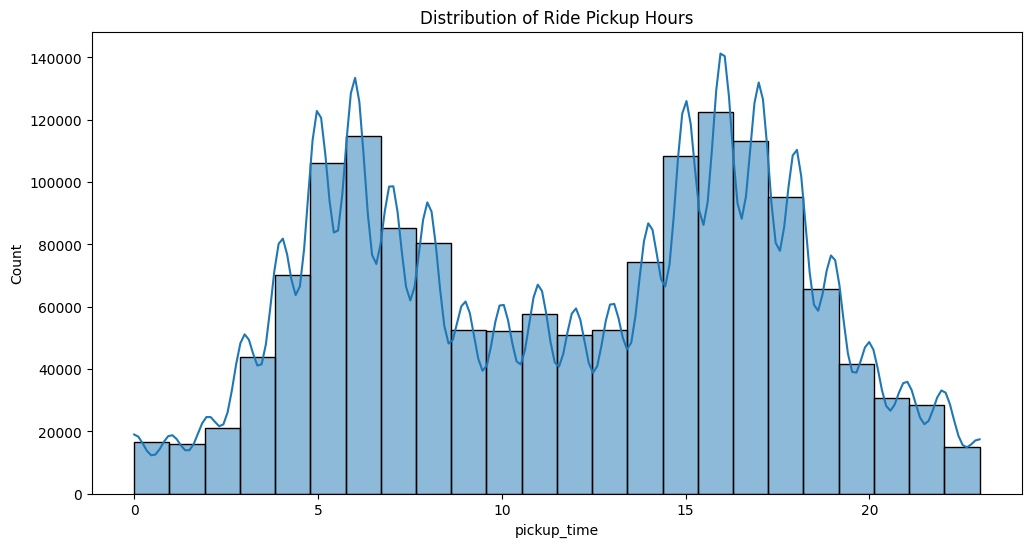

In [16]:
# EDA
plt.figure(figsize=(12, 6))  # width=12 inches, height=6 inches
sns.histplot(ridewise['pickup_time'].dt.hour, bins=24, kde=True)
plt.title("Distribution of Ride Pickup Hours")
plt.show()


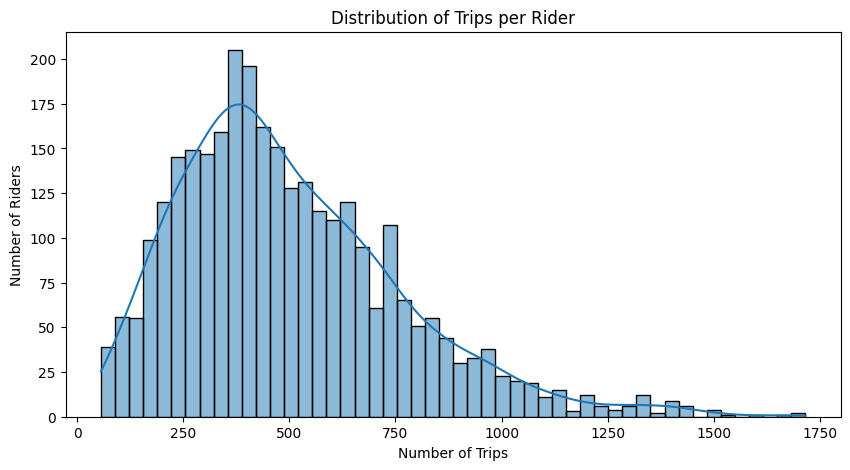

In [17]:
# Count trips per rider
rider_counts = ridewise['rider_id'].value_counts()

# Plot distribution
plt.figure(figsize=(10,5))
sns.histplot(rider_counts, bins=50, kde=True)
plt.title("Distribution of Trips per Rider")
plt.xlabel("Number of Trips")
plt.ylabel("Number of Riders")
plt.show()

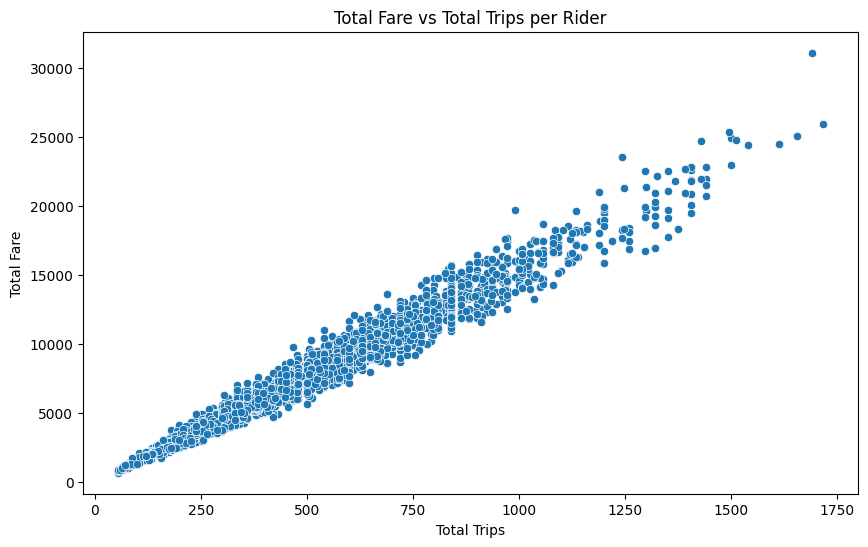

In [18]:
rider_summary = ridewise.groupby('rider_id').agg(
    total_trips=('rider_id', 'count'),
    total_fare=('fare', 'sum')
).reset_index()

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=rider_summary,
    x='total_trips',
    y='total_fare'
)
plt.title("Total Fare vs Total Trips per Rider")
plt.xlabel("Total Trips")
plt.ylabel("Total Fare")
plt.show()


In [19]:
churn_days = 360
cutoff_date = ridewise['last_active'].max() - pd.Timedelta(days=churn_days)
cutoff_date

Timestamp('2024-05-02 16:20:56.061000')

In [20]:
# Flag churned riders
riders_churn = ridewise.groupby('rider_id')['last_active'].max().reset_index()
print(riders_churn)

     rider_id             last_active
0      R00000 2025-04-26 21:49:08.083
1      R00004 2025-04-25 03:59:33.772
2      R00006 2025-04-26 09:47:16.062
3      R00008 2025-04-27 16:15:17.853
4      R00011 2025-04-18 12:19:36.354
...       ...                     ...
3018   R09988 2025-04-27 13:33:39.605
3019   R09989 2025-04-26 22:55:41.937
3020   R09990 2025-04-26 08:26:32.260
3021   R09997 2025-04-22 22:09:26.207
3022   R09998 2025-04-26 07:20:52.648

[3023 rows x 2 columns]


In [21]:
riders_churn['churned'] = riders_churn['last_active'] < cutoff_date
print(riders_churn['churned'])

0       False
1       False
2       False
3       False
4       False
        ...  
3018    False
3019    False
3020    False
3021    False
3022    False
Name: churned, Length: 3023, dtype: bool


In [22]:
# Merge churn flag to main dataframe
ridewise = ridewise.merge(riders_churn[['rider_id', 'churned']], on='rider_id', how='left')
ridewise

,trip_id,rider_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,...,promo_name,promo_type,promo_value,start_date,end_date,target_segment,ab_test_groups,test_allocation,success_metric,churned
0,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 22:59:48+00:00,2024-10-28 23:12:48+00:00,6.675266,...,First Ride Discount,discount,0.3,45773,45783,New,['All'],[1.0],Usage Frequency,False
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 22:59:48+00:00,2024-10-28 23:12:48+00:00,6.675266,...,First Ride Discount,discount,0.3,45773,45796,New,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",ROI,False
2,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 22:59:48+00:00,2024-10-28 23:12:48+00:00,6.675266,...,Loyalty Bonus,points,100.0,45773,45783,Gold+,['All'],[1.0],Usage Frequency,False
3,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 22:59:48+00:00,2024-10-28 23:12:48+00:00,6.675266,...,First Ride Discount,discount,0.3,45773,45783,New,['All'],[1.0],ROI,False
4,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 22:59:48+00:00,2024-10-28 23:12:48+00:00,6.675266,...,First Ride Discount,discount,0.3,45773,45785,New,['All'],[1.0],Conversion Rate,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1513777,T199999,R07749,D04894,13.47,1.0,0.00,Card,2024-05-24 16:14:39+00:00,2024-05-24 16:46:39+00:00,30.234277,...,First Ride Discount,discount,0.3,45773,45790,New,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",ROI,False
1513778,T199999,R07749,D04894,13.47,1.0,0.00,Card,2024-05-24 16:14:39+00:00,2024-05-24 16:46:39+00:00,30.234277,...,Peak Hour Pass,surge_waiver,1.0,45773,45799,All,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",Conversion Rate,False
1513779,T199999,R07749,D04894,13.47,1.0,0.00,Card,2024-05-24 16:14:39+00:00,2024-05-24 16:46:39+00:00,30.234277,...,Peak Hour Pass,surge_waiver,1.0,45773,45793,All,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",ROI,False
1513780,T199999,R07749,D04894,13.47,1.0,0.00,Card,2024-05-24 16:14:39+00:00,2024-05-24 16:46:39+00:00,30.234277,...,Referral Special,credit,15.0,45773,45795,Active,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",ROI,False


In [23]:
total_riders = riders_churn['rider_id'].nunique()
churned_riders = riders_churn['churned'].sum()
attrition_rate = churned_riders / total_riders * 100

print(f"Overall attrition rate (last {churn_days} days): {attrition_rate:.2f}%")

Overall attrition rate (last 360 days): 0.00%


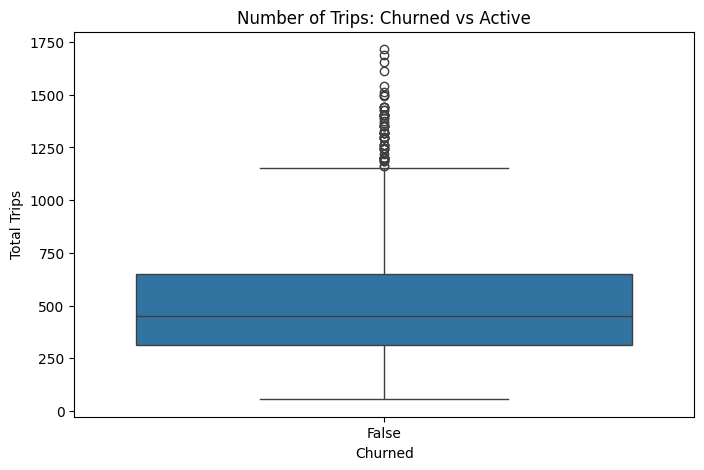

In [24]:
# Total trips per rider
trips_per_rider = ridewise.groupby('rider_id')['trip_id'].count().reset_index()
trips_per_rider.columns = ['rider_id', 'total_trips']

# Merge with churn
trips_per_rider = trips_per_rider.merge(riders_churn[['rider_id','churned']], on='rider_id')

plt.figure(figsize=(8,5))
sns.boxplot(data=trips_per_rider, x='churned', y='total_trips')
plt.title("Number of Trips: Churned vs Active")
plt.xlabel("Churned")
plt.ylabel("Total Trips")
plt.show()

In [25]:
ridewise.columns

Index(['trip_id', 'rider_id', 'driver_id', 'fare', 'surge_multiplier', 'tip',
       'payment_type', 'pickup_time', 'dropoff_time', 'pickup_lat',
       'pickup_lng', 'dropoff_lat', 'dropoff_lng', 'weather', 'city',
       'loyalty_status', 'rating', 'vehicle_type', 'signup_date',
       'last_active', 'city_drivers', 'acceptance_rate', 'signup_date_riders',
       'loyalty_status_riders', 'age', 'city_riders', 'avg_rating_given',
       'churn_prob', 'referred_by', 'session_id', 'session_time',
       'time_on_app', 'pages_visited', 'converted', 'city_sessions',
       'loyalty_status_sessions', 'promo_id', 'promo_name', 'promo_type',
       'promo_value', 'start_date', 'end_date', 'target_segment',
       'ab_test_groups', 'test_allocation', 'success_metric', 'churned'],
      dtype='object')

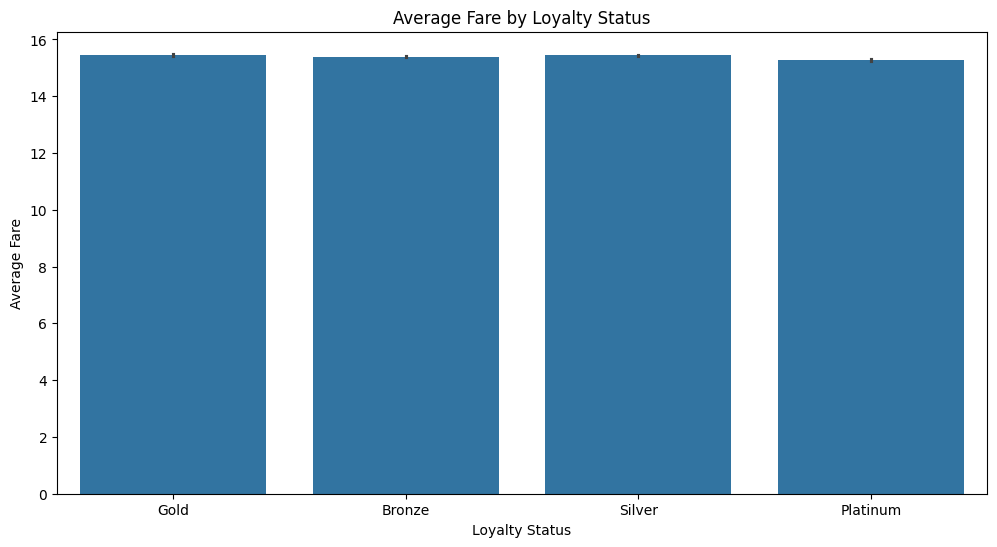

In [26]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=ridewise,
    x="loyalty_status",
    y="fare"
)
plt.xlabel("Loyalty Status")
plt.ylabel("Average Fare")
plt.title("Average Fare by Loyalty Status")
plt.show()

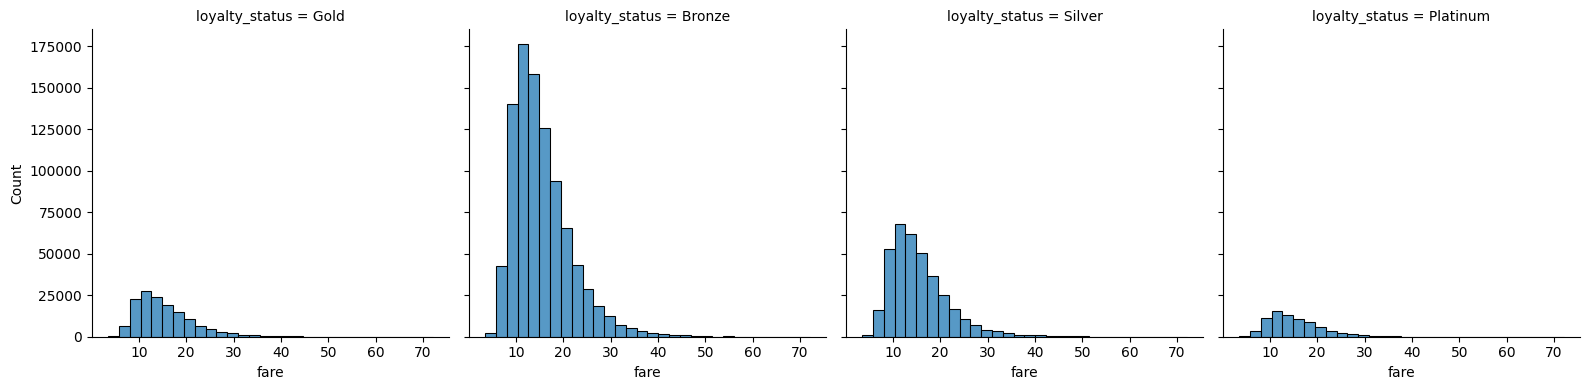

In [27]:
sns.displot(
    data=ridewise,
    x="fare",
    col="loyalty_status",
    bins=30,
    height=4,
    aspect=1
)


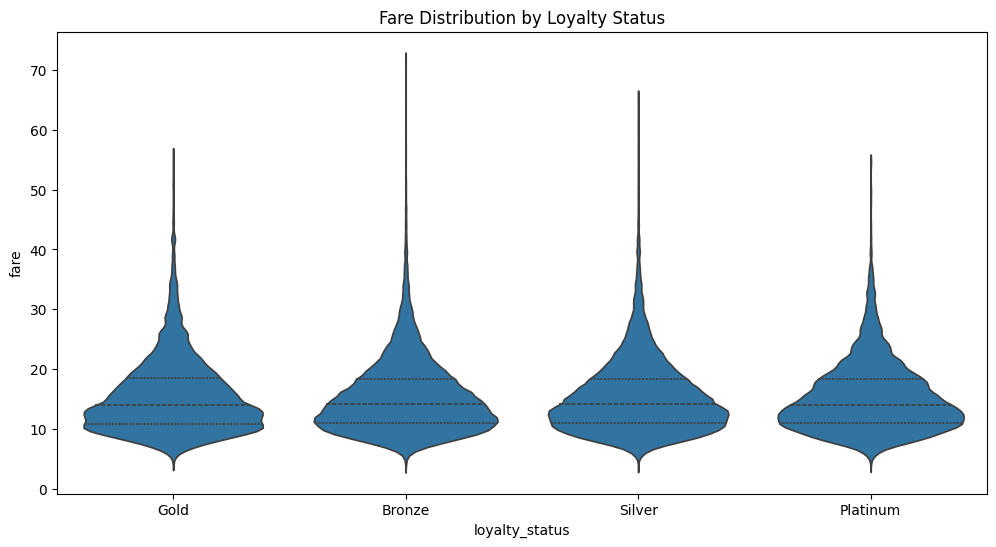

In [28]:
plt.figure(figsize=(12,6))
sns.violinplot(
    data=ridewise,
    x="loyalty_status",
    y="fare",
    inner="quartile"
)
plt.title("Fare Distribution by Loyalty Status")
plt.show()

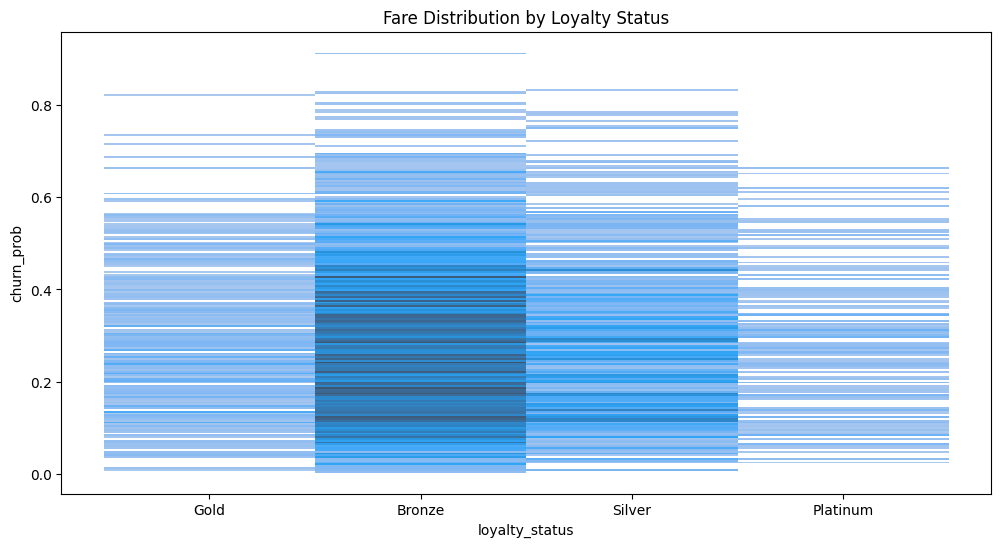

In [29]:
plt.figure(figsize=(12,6))
sns.histplot(
    data=ridewise,
    x="loyalty_status",
    y="churn_prob",

)
plt.title("Fare Distribution by Loyalty Status")
plt.show()

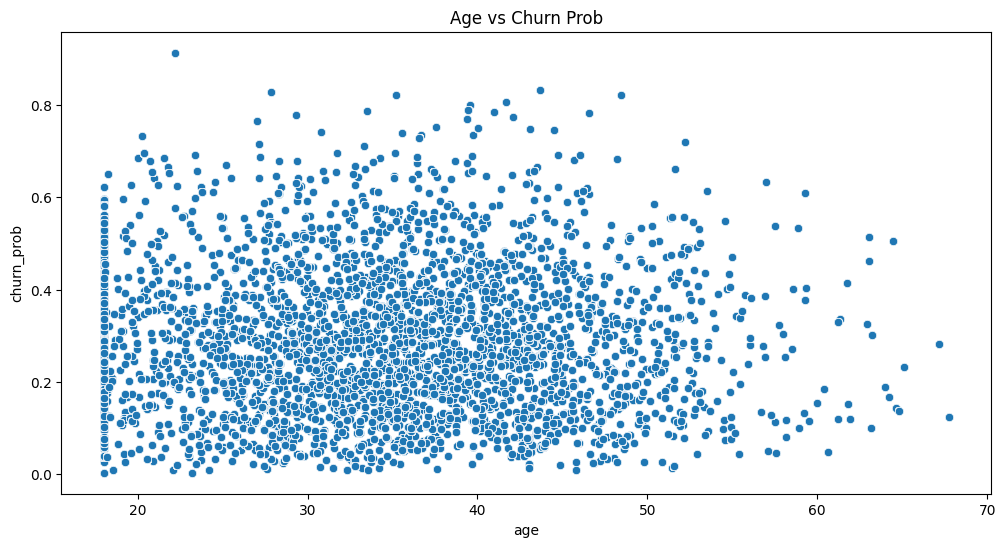

In [30]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=ridewise, x="age", y="churn_prob")
plt.title("Age vs Churn Prob")
plt.xlabel("age")
plt.ylabel("churn_prob")
plt.show()

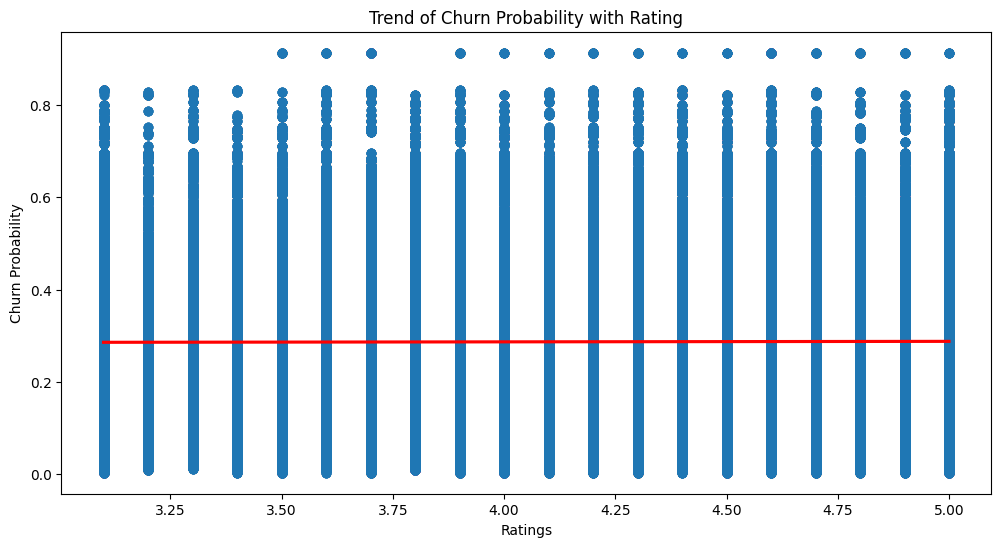

In [31]:
plt.figure(figsize=(12,6))
sns.regplot(
    data=ridewise,
    x="rating",
    y="churn_prob",
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)
plt.title("Trend of Churn Probability with Rating")
plt.xlabel("Ratings")
plt.ylabel("Churn Probability")
plt.show()

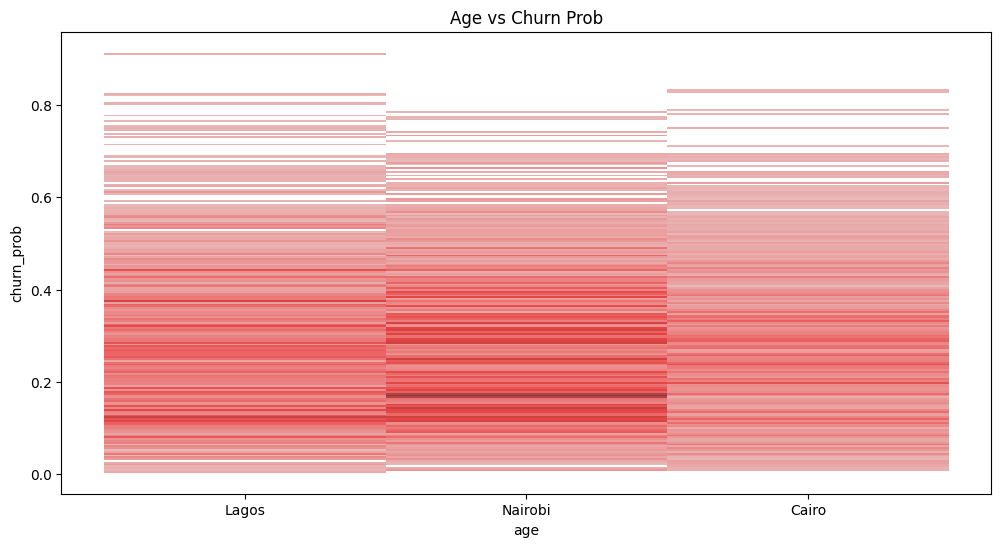

In [32]:
plt.figure(figsize=(12,6))
sns.histplot(data=ridewise, x="city_drivers", y="churn_prob", color = "brown")
plt.title("Age vs Churn Prob")
plt.xlabel("age")
plt.ylabel("churn_prob")
plt.show()

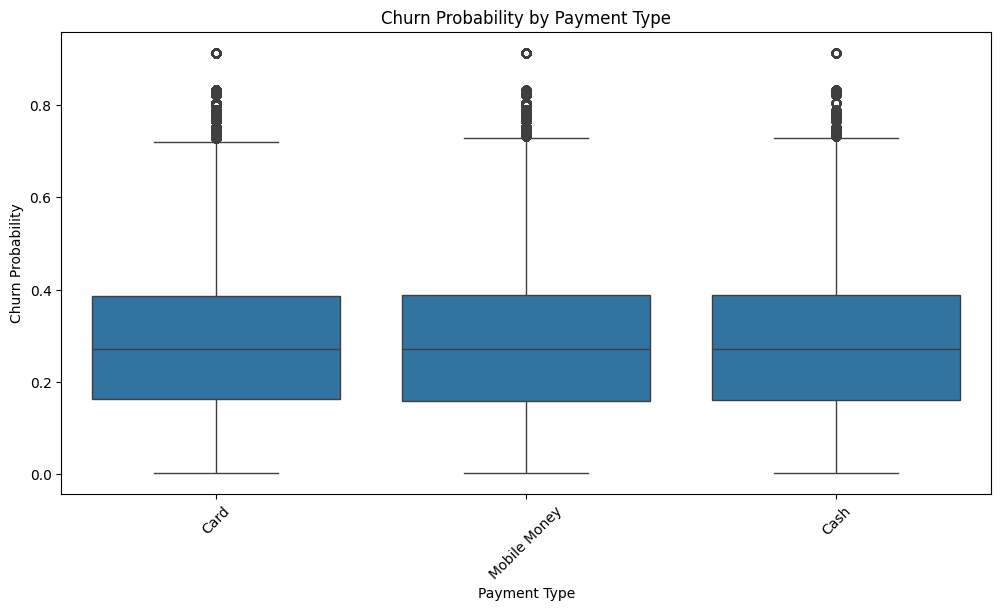

In [33]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=ridewise,
    x="payment_type",
    y="churn_prob"
)
plt.title("Churn Probability by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Churn Probability")
plt.xticks(rotation=45)
plt.show()

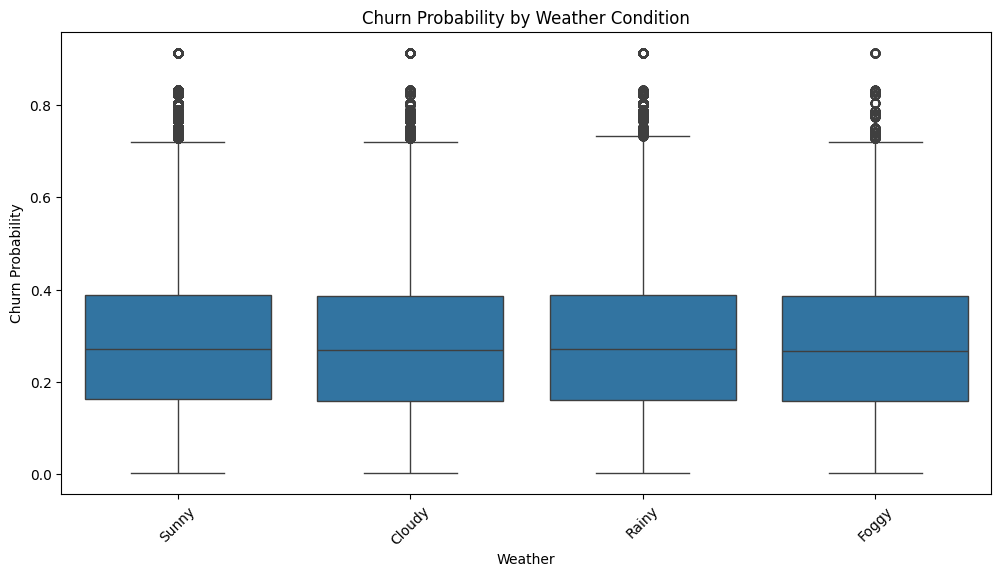

In [34]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=ridewise,
    x="weather",
    y="churn_prob"
)
plt.title("Churn Probability by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Churn Probability")
plt.xticks(rotation=45)
plt.show()

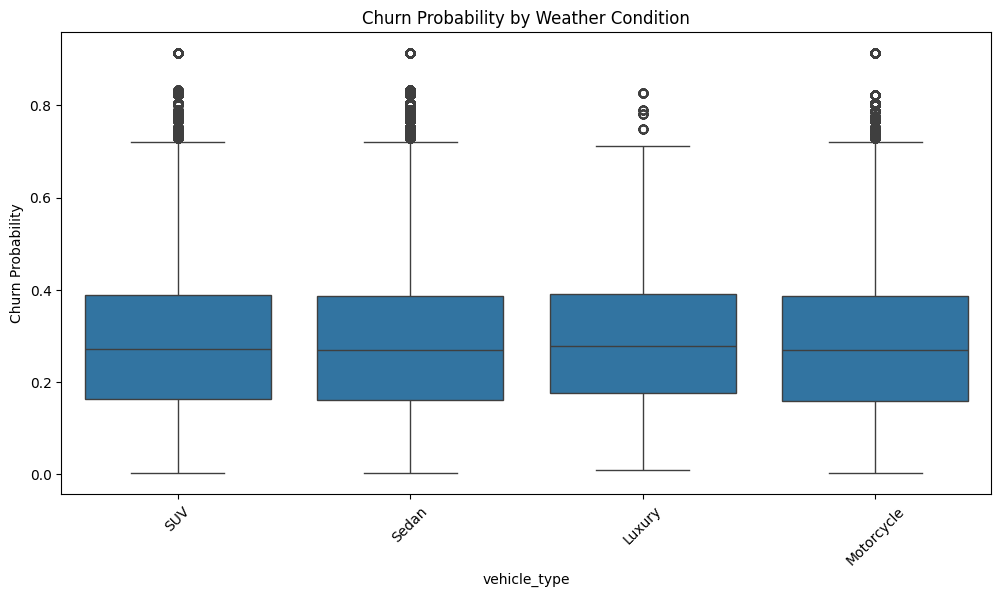

In [35]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=ridewise,
    x="vehicle_type",
    y="churn_prob"
)
plt.title("Churn Probability by Weather Condition")
plt.xlabel("vehicle_type")
plt.ylabel("Churn Probability")
plt.xticks(rotation=45)
plt.show()

In [36]:
ridewise.columns

Index(['trip_id', 'rider_id', 'driver_id', 'fare', 'surge_multiplier', 'tip',
       'payment_type', 'pickup_time', 'dropoff_time', 'pickup_lat',
       'pickup_lng', 'dropoff_lat', 'dropoff_lng', 'weather', 'city',
       'loyalty_status', 'rating', 'vehicle_type', 'signup_date',
       'last_active', 'city_drivers', 'acceptance_rate', 'signup_date_riders',
       'loyalty_status_riders', 'age', 'city_riders', 'avg_rating_given',
       'churn_prob', 'referred_by', 'session_id', 'session_time',
       'time_on_app', 'pages_visited', 'converted', 'city_sessions',
       'loyalty_status_sessions', 'promo_id', 'promo_name', 'promo_type',
       'promo_value', 'start_date', 'end_date', 'target_segment',
       'ab_test_groups', 'test_allocation', 'success_metric', 'churned'],
      dtype='object')

In [37]:
# Drop Irrevelavant Columns

ridewise= ridewise.drop(["success_metric","trip_id","referred_by","city_riders","last_active","city_drivers","rider_id","driver_id","surge_multiplier","dropoff_lng","signup_date","pickup_time","dropoff_time","pickup_lat","pickup_lng","dropoff_lat","signup_date_riders","loyalty_status_riders","session_id","session_time","churn_prob","loyalty_status_sessions","promo_id","start_date","end_date","ab_test_groups","test_allocation","churned"],axis = 1 )

In [38]:
ridewise.head(2)

,fare,tip,payment_type,weather,city,loyalty_status,rating,vehicle_type,acceptance_rate,age,avg_rating_given,time_on_app,pages_visited,converted,city_sessions,promo_name,promo_type,promo_value,target_segment
0,8.73,0.02,Card,Sunny,Lagos,Gold,4.9,SUV,0.62925,37.051088,4.7,2.0,5.0,0.0,Lagos,First Ride Discount,discount,0.3,New
1,8.73,0.02,Card,Sunny,Lagos,Gold,4.9,SUV,0.62925,37.051088,4.7,2.0,5.0,0.0,Lagos,First Ride Discount,discount,0.3,New


In [39]:
# Initiate encoder library
from sklearn.preprocessing import LabelEncoder

In [40]:
encoder = LabelEncoder()

In [41]:
# Import necessary libraries
#from sklearn.preprocessing import LabelEncoder

# Create label encoders for each categorical column
#payment_encoder = LabelEncoder()
#promo_name_encoder = LabelEncoder()
#promo_type_encoder = LabelEncoder()
#target_segment_encoder = LabelEncoder()
#success_metric_encoder = LabelEncoder()
#weather_encoder = LabelEncoder()
#city_encoder = LabelEncoder()
#vehicle_type_encoder = LabelEncoder()

# Apply the encoders to transform each column
#ridewise["payment_type"] = payment_encoder.fit_transform(ridewise["payment_type"])
#ridewise["promo_name"] = promo_name_encoder.fit_transform(ridewise["promo_name"])
#ridewise["promo_type"] = promo_type_encoder.fit_transform(ridewise["promo_type"])
#ridewise["target_segment"] = target_segment_encoder.fit_transform(ridewise["target_segment"])  # Fixed column name
#ridewise["success_metric"] = success_metric_encoder.fit_transform(ridewise["success_metric"])  # Fixed column name
#ridewise["weather"] = weather_encoder.fit_transform(ridewise["weather"])  # Fixed column name
#ridewise["city"] = city_encoder.fit_transform(ridewise["city"])  # Fixed column name
#ridewise["vehicle_type"] = vehicle_type_encoder.fit_transform(ridewise["vehicle_type"])  # Fixed column name
# Note: The last two lines in the original code were duplicates, so I removed them

payment_encoder = LabelEncoder()
promo_name_encoder = LabelEncoder()
promo_type_encoder = LabelEncoder()
target_segment_encoder = LabelEncoder()
weather_encoder = LabelEncoder()
city_encoder = LabelEncoder()
vehicle_type_encoder = LabelEncoder()
loyalty_status = LabelEncoder()
city_sessions =LabelEncoder()


ridewise["payment_type"] = payment_encoder.fit_transform(ridewise["payment_type"])
ridewise["promo_name"] = promo_name_encoder.fit_transform(ridewise["promo_name"])
ridewise["promo_type"] = promo_type_encoder.fit_transform(ridewise["promo_type"])
ridewise["target_segment"] = target_segment_encoder.fit_transform(ridewise["target_segment"])   
ridewise["weather"] = weather_encoder.fit_transform(ridewise["weather"])  
ridewise["city"] = city_encoder.fit_transform(ridewise["city"])  
ridewise["vehicle_type"] = vehicle_type_encoder.fit_transform(ridewise["vehicle_type"])
ridewise["loyalty_status"] = loyalty_status.fit_transform(ridewise["loyalty_status"])
ridewise["city_sessions"] = city_sessions.fit_transform(ridewise["city_sessions"])




In [42]:
ridewise.head(2)

,fare,tip,payment_type,weather,city,loyalty_status,rating,vehicle_type,acceptance_rate,age,avg_rating_given,time_on_app,pages_visited,converted,city_sessions,promo_name,promo_type,promo_value,target_segment
0,8.73,0.02,0,3,1,1,4.9,2,0.62925,37.051088,4.7,2.0,5.0,0.0,1,0,1,0.3,3
1,8.73,0.02,0,3,1,1,4.9,2,0.62925,37.051088,4.7,2.0,5.0,0.0,1,0,1,0.3,3


In [43]:
if 'city_riders' in trips.columns:
    print("Column exists in driver")
else:
    print("no")

no


In [44]:
ridewise.columns

Index(['fare', 'tip', 'payment_type', 'weather', 'city', 'loyalty_status',
       'rating', 'vehicle_type', 'acceptance_rate', 'age', 'avg_rating_given',
       'time_on_app', 'pages_visited', 'converted', 'city_sessions',
       'promo_name', 'promo_type', 'promo_value', 'target_segment'],
      dtype='object')

In [45]:
#Scale numerical data
from sklearn.preprocessing import StandardScaler

In [46]:
scaler = StandardScaler()

In [47]:
ridewise.head(2)

,fare,tip,payment_type,weather,city,loyalty_status,rating,vehicle_type,acceptance_rate,age,avg_rating_given,time_on_app,pages_visited,converted,city_sessions,promo_name,promo_type,promo_value,target_segment
0,8.73,0.02,0,3,1,1,4.9,2,0.62925,37.051088,4.7,2.0,5.0,0.0,1,0,1,0.3,3
1,8.73,0.02,0,3,1,1,4.9,2,0.62925,37.051088,4.7,2.0,5.0,0.0,1,0,1,0.3,3


In [48]:
numerical_cols_to_scale = ["promo_value","fare","tip","rating","acceptance_rate","time_on_app","pages_visited","age","avg_rating_given"]
ridewise[numerical_cols_to_scale] = scaler.fit_transform(ridewise[numerical_cols_to_scale])

In [49]:
ridewise["converted"].value_counts()

converted
0.0    1278980
1.0     234802
Name: count, dtype: int64

In [50]:
ridewise["converted"].value_counts(normalize = True)*100

converted
0.0    84.489048
1.0    15.510952
Name: proportion, dtype: float64

<Axes: xlabel='converted', ylabel='Count'>

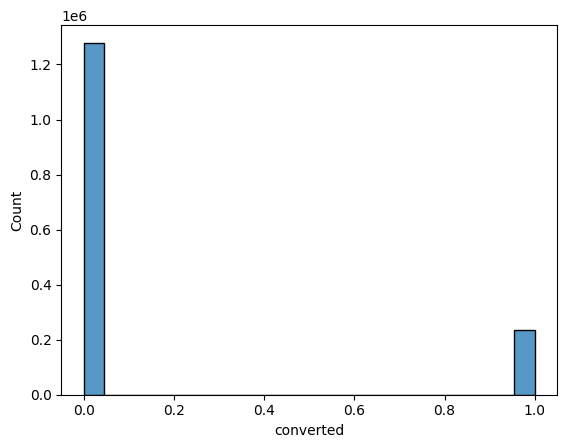

In [51]:
sns.histplot(x=ridewise["converted"])

In [52]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [53]:
from imblearn.over_sampling import SMOTE

In [54]:
X = ridewise.drop("converted", axis = 1)
y = ridewise["converted"]

In [55]:
smote = SMOTE(random_state = 42)

In [56]:
X_resampled,y_resampled = smote.fit_resample(X,y)

In [57]:
y_resampled.value_counts()

converted
0.0    1278980
1.0    1278980
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='Count'>

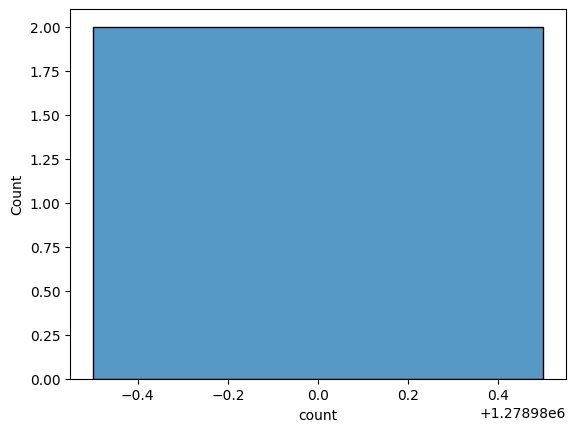

In [58]:
sns.histplot(x=y_resampled.value_counts())

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.2, random_state =42)

In [61]:
from sklearn.linear_model import LogisticRegression


In [62]:
model = LogisticRegression(random_state = 42)

In [63]:
model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [64]:
# Coefficient and Intercept
coef = model.coef_
intercept =  model.intercept_
print(f"Coeffiient: {coef}")
print(f"Intercept: {intercept}")


Coeffiient: [[-0.00862343  0.08742932 -0.00259891  0.00222125  0.00302919  0.07745365
   0.00209542  0.01089177  0.00687654 -0.01769044 -0.04357891  0.10598985
   0.08493309  0.00302919 -0.49268574  0.00059116  0.00170837 -0.49583686]]
Intercept: [-0.32952518]


In [65]:
y_pred = model.predict(X_test)

In [66]:
#from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [67]:
conversion_prob = model.predict_proba(X_test)[:, 1]


In [68]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)


0.8453446163094495

In [69]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, conversion_prob)


0.565790107021385

In [70]:
from sklearn.metrics import classification_report, confusion_matrix

In [71]:
report = classification_report(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)

In [72]:
print("Logistic Regression Classification Report")
print(report)

Logistic Regression Classification Report
              precision    recall  f1-score   support

         0.0       0.85      1.00      0.92    255934
         1.0       0.50      0.00      0.00     46823

    accuracy                           0.85    302757
   macro avg       0.67      0.50      0.46    302757
weighted avg       0.79      0.85      0.77    302757



In [73]:
from sklearn.ensemble import RandomForestClassifier 

In [74]:
rf_model = RandomForestClassifier(random_state = 42, class_weight = "balanced")
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
report = classification_report(y_test, y_pred)
print("Random Forest Classification Report")
print(report)

Random Forest Classification Report
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00    255934
         1.0       0.99      0.96      0.98     46823

    accuracy                           0.99    302757
   macro avg       0.99      0.98      0.99    302757
weighted avg       0.99      0.99      0.99    302757



In [75]:
from sklearn.cluster import KMeans

In [76]:
# Elbow Method
wcss = [] #within clusters sum of squares

for k in range (1,11):
    model = KMeans(n_clusters = k, random_state = 42)
    model.fit(ridewise)
    wcss.append(model.inertia_)

In [77]:
wcss

[26444857.628816858,
 23438544.152694657,
 21252412.284147546,
 20340943.952584185,
 19832669.887464315,
 19026103.513372604,
 18280815.40718182,
 17414229.406752735,
 17131210.00107924,
 16304982.729928497]

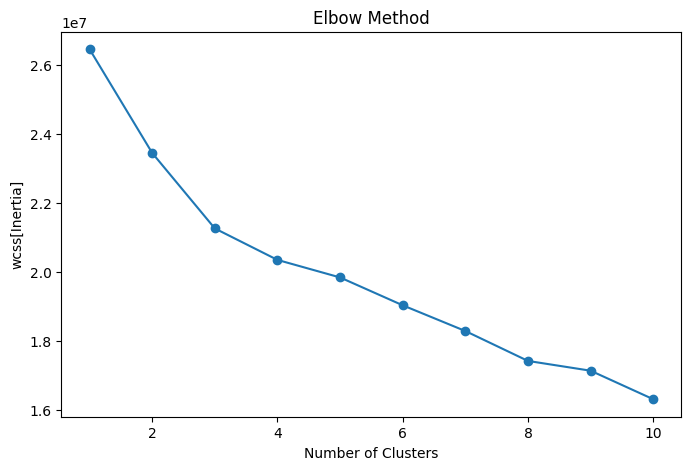

In [78]:
plt.figure(figsize = (8,5))
plt.plot(range(1,11), wcss, marker =  "o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("wcss[Inertia]")
plt.show()

In [79]:
!pip install kneed


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [80]:

from kneed import KneeLocator


wcss = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)  # Replace X with your dataset
    wcss.append(kmeans.inertia_)

# Use KneeLocator to find elbow
knee = KneeLocator(K, wcss, curve='convex', direction='decreasing')

print("Optimal number of clusters:", knee.elbow)

Optimal number of clusters: 8


In [81]:
from sklearn.metrics import silhouette_score

In [82]:
#Silhoute Score

#silhouette_scores =[]
#for k in range(2,11):
#    model = KMeans(n_clusters = k, random_state = 42)
 #   model.fit(ridewise)
#    silhouette_scores.append(silhouette_score(ridewise, model.labels_))

In [83]:
#plt.figure(figsize = (8,5))
#plt.plot(range(2,11), silhouette_scores, marker = "o")
#plt.title("Silhouette scores")
#plt.xlabel("Number of Clusters")
#plt.ylabel("Silhouette Score")
#plt.show()

In [84]:
#print(len(silhouette_score))

In [85]:
#Apply KMeans Clustering
optimal_k = 8
model = KMeans(n_clusters = optimal_k, random_state = 42)

In [86]:
model.fit(ridewise)

KMeans(random_state=42)

In [87]:
# Revert to using the raw data for assessment of the model
model.labels_

ridewise["Cluster"] = model.labels_

In [88]:
ridewise.head(4)

,fare,tip,payment_type,weather,city,loyalty_status,rating,vehicle_type,acceptance_rate,age,avg_rating_given,time_on_app,pages_visited,converted,city_sessions,promo_name,promo_type,promo_value,target_segment,Cluster
0,-1.079962,-0.403881,0,3,1,1,1.226391,2,-0.348471,0.22265,0.567447,-0.454038,1.449082,0.0,1,0,1,-0.638655,3,5
1,-1.079962,-0.403881,0,3,1,1,1.226391,2,-0.348471,0.22265,0.567447,-0.454038,1.449082,0.0,1,0,1,-0.638655,3,5
2,-1.079962,-0.403881,0,3,1,1,1.226391,2,-0.348471,0.22265,0.567447,-0.454038,1.449082,0.0,1,1,2,1.649290,2,2
3,-1.079962,-0.403881,0,3,1,1,1.226391,2,-0.348471,0.22265,0.567447,-0.454038,1.449082,0.0,1,0,1,-0.638655,3,5


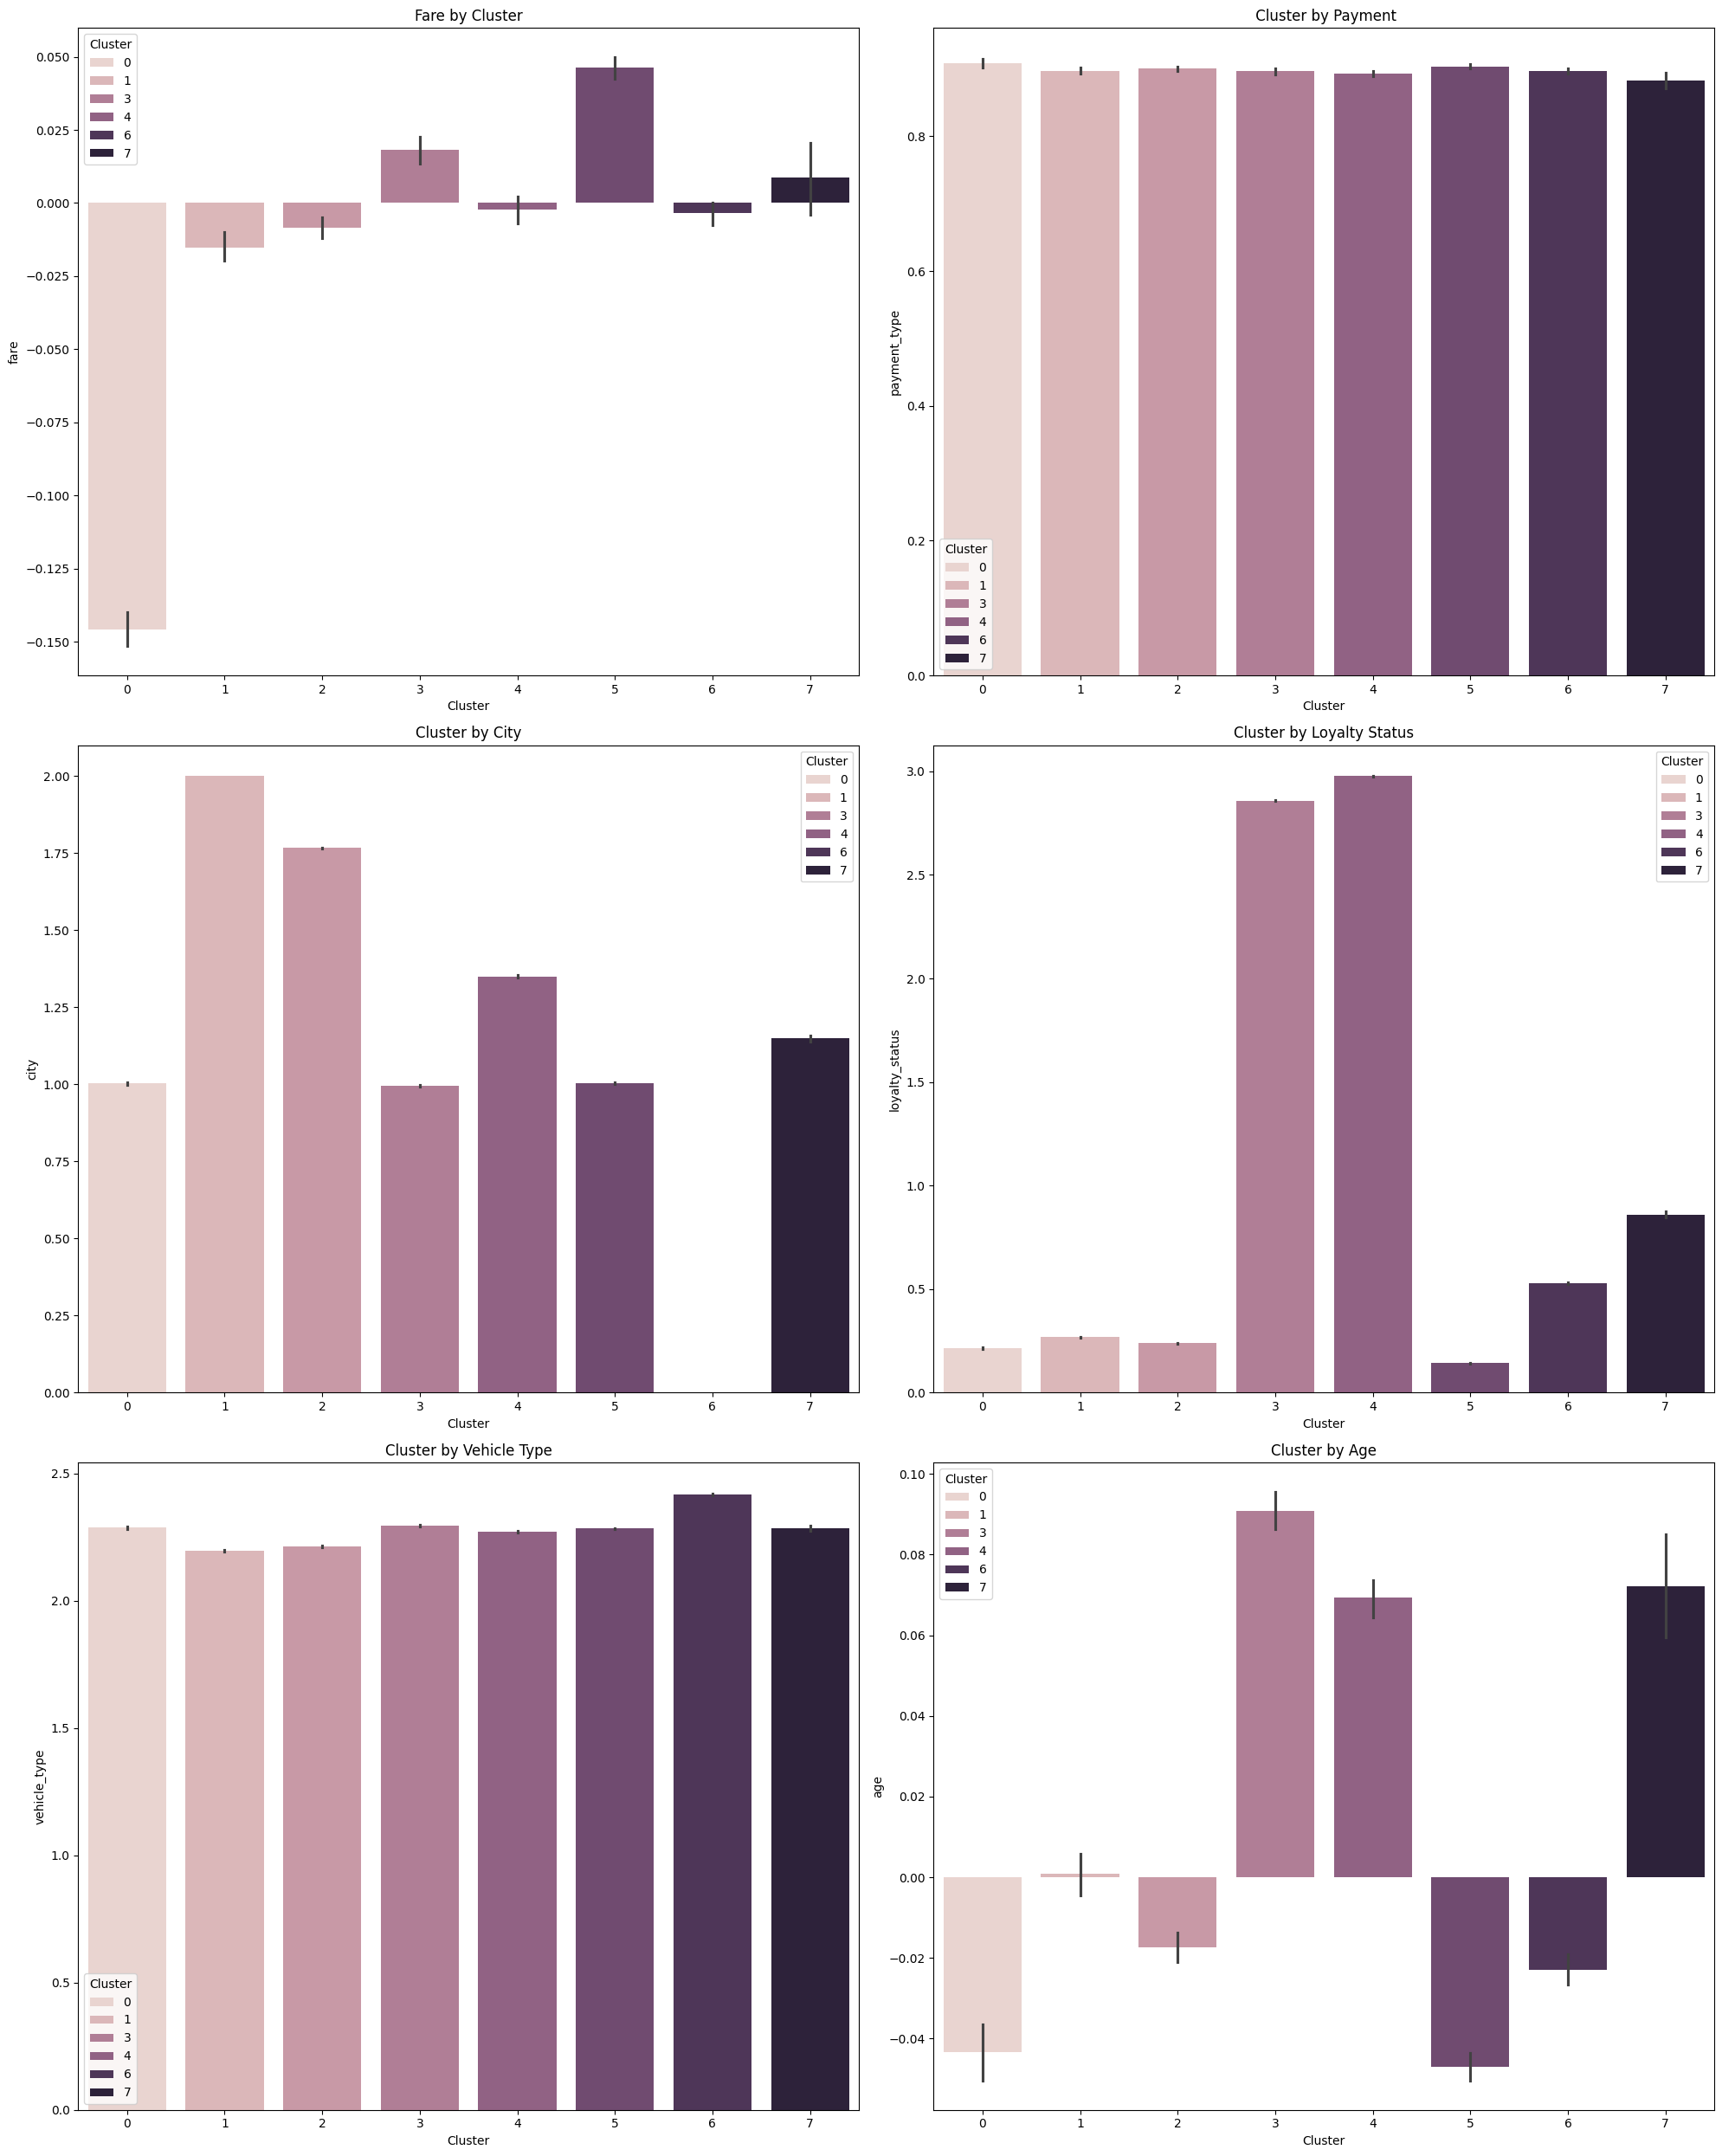

In [89]:
plt.figure(figsize = (20,25))
plt.subplot(3,2,1)
sns.barplot(x="Cluster",y="fare", data = ridewise, hue ="Cluster")
plt.title("Fare by Cluster")

plt.subplot(3,2,2)
sns.barplot(x="Cluster",y="payment_type", data = ridewise , hue ="Cluster")
plt.title(" Cluster by Payment")

plt.subplot(3,2,3)
sns.barplot(x="Cluster",y="city", data = ridewise, hue ="Cluster")
plt.title("Cluster by City")

plt.subplot(3,2,4)
sns.barplot(x="Cluster",y="loyalty_status", data = ridewise , hue ="Cluster")
plt.title("Cluster by Loyalty Status")

plt.subplot(3,2,5)
sns.barplot(x="Cluster",y="vehicle_type", data = ridewise, hue ="Cluster")
plt.title("Cluster by Vehicle Type")

plt.subplot(3,2,6)
sns.barplot(x="Cluster",y="age", data = ridewise, hue ="Cluster")
plt.title("Cluster by Age")

plt.tight_layout()

Ridewise

🔹 Cluster 0 – Low Fare, Younger, Low Loyalty
	•	Fare: Strongly below average (lowest of all clusters)
	•	Age: Below average (younger users)
	•	Loyalty: Very low
	•	Payment: Similar to others
	•	Vehicle Type: Around average
	•	City: Around average

Profile:
Price-sensitive, younger occasional riders. Likely short, low-cost trips with minimal brand loyalty.

⸻

🔹 Cluster 1 – Slightly Low Fare, Young, Low Loyalty
	•	Fare: Slightly below average
	•	Age: Around average/slightly above
	•	Loyalty: Low
	•	City: Highest city index (possibly concentrated in one major city)
	•	Vehicle: Slightly below average

Profile:
Urban riders in a dominant city, moderate age, low loyalty. Possibly casual but consistent users.

⸻

🔹 Cluster 2 – Low-Mid Fare, Slightly Younger
	•	Fare: Slightly below average
	•	Age: Slightly below average
	•	Loyalty: Low
	•	City: High city index
	•	Vehicle: Around average

Profile:
Young urban riders with moderate usage but still not loyal customers.

⸻

🔹 Cluster 3 – High Fare, Older, Very Loyal
	•	Fare: Above average
	•	Age: Highest positive age deviation
	•	Loyalty: Very high
	•	City: Slightly below city 1 & 2
	•	Vehicle: Slightly above average

Profile:
Premium, older, highly loyal customers. Likely frequent users with higher spend per trip.

⸻

🔹 Cluster 4 – Near-Average Fare, Very Loyal
	•	Fare: Slightly below/near average
	•	Age: Above average
	•	Loyalty: Highest
	•	City: Moderate
	•	Vehicle: Slightly above average

Profile:
Highly loyal mid-to-older age riders, steady spenders but not necessarily premium fare.

⸻

🔹 Cluster 5 – Highest Fare, Younger, Low Loyalty
	•	Fare: Highest positive deviation
	•	Age: One of the youngest clusters
	•	Loyalty: Very low
	•	Vehicle: Slightly above average
	•	City: Slightly below average

Profile:
High-spending but not loyal. Possibly business or situational riders (e.g., airport trips). Strong revenue potential but churn risk.

⸻

🔹 Cluster 6 – Low Fare, Young, Low–Mid Loyalty
	•	Fare: Below average
	•	Age: Below average
	•	Loyalty: Low–moderate
	•	Vehicle: Highest vehicle index
	•	City: Lowest city index

Profile:
Younger riders in a specific city, lower spend but slightly more engaged than clusters 0–2.

⸻

🔹 Cluster 7 – Slightly Low Fare, Older, Moderate Loyalty
	•	Fare: Slightly below average
	•	Age: Above average
	•	Loyalty: Moderate
	•	Vehicle: Around average
	•	City: Mid-range

Profile:
Older, steady but not premium users. Moderate loyalty and stable usage.


📊 Strategic Segmentation Summary

Cluster	 Revenue -Level	      Loyalty	   Age-Group	         Strategic Label
0	    Very Low	         Very Low	   Young	             Price-sensitive.occasional
1	      Low	              Low	        Mid	                  Urban casual
2	    Low-Mid	              Low	       Young	             Emerging urban
3	     High	           Very High	   Older	             Premium loyal
4	     Mid	            Highest	       Older	             Core loyal
5	   Very High	         Very Low	   Young	             High value but churn risk
6	    Low	                Low-Mid	       Young	            City-specific regular
7	    Mid	                Moderate	   Older	            Stable mainstream
 



🎯 Cluster-Based Marketing Strategy

🔹 Cluster 0 – Price-Sensitive Occasionals

Profile: Very low fare, young, low loyalty

Strategy:
	•	Push discount codes & referral incentives
	•	Offer first 5 rides discount bundles
	•	Use gamification (ride streak rewards)
	•	Promote cheaper vehicle categories

Goal: Increase frequency & convert to habitual users

⸻

🔹 Cluster 1 – Urban Casual Riders

Profile: Low fare, concentrated city, low loyalty

Strategy:
	•	City-specific promotions
	•	Geo-targeted push notifications during peak times
	•	Subscription for commute discounts

Goal: Convert occasional city riders into regular commuters

⸻

🔹 Cluster 2 – Young Emerging Riders

Profile: Low-mid fare, young, low loyalty

Strategy:
	•	Student discounts
	•	Social media campaigns
	•	In-app ride bundles (e.g., 10 rides/month discount)

Goal: Build early brand loyalty

⸻

🔹 Cluster 3 – Premium Loyal Customers 💎

Profile: High fare, older, very loyal

Strategy:
	•	VIP tier rewards
	•	Priority support
	•	Premium vehicle upgrades
	•	Corporate/business ride programs

Goal: Retain & increase lifetime value

⸻

🔹 Cluster 4 – Core Loyal Base

Profile: Moderate fare, highest loyalty

Strategy:
	•	Loyalty milestone rewards
	•	Anniversary bonuses
	•	Referral ambassador programs

Goal: Maintain loyalty & encourage advocacy

⸻

🔹 Cluster 5 – High Revenue but Low Loyalty 🚨

Profile: Highest fare, younger, low loyalty

Strategy:
	•	Personalised retention offers
	•	Post-ride targeted discounts
	•	Subscription plans for frequent long-distance riders
	•	Triggered offers after inactivity

Goal: Reduce churn — this is your biggest risk segment

⸻

🔹 Cluster 6 – City-Specific Young Riders

Profile: Low fare, young, moderate engagement

Strategy:
	•	City-level partnerships (events, nightlife, universities)
	•	Time-based offers (weekend promos)

Goal: Increase spend per ride

⸻

🔹 Cluster 7 – Stable Older Users

Profile: Moderate loyalty, older

Strategy:
	•	Comfort-focused messaging
	•	Safety & reliability campaigns
	•	Mid-tier loyalty upgrades

Goal: Move them toward premium loyalty (Cluster 3/4 behavior)

⸻

📈 Business Priority Ranking
	1.	Cluster 5 – Immediate retention focus (high revenue risk)
	2.	Cluster 3 & 4 – Protect and reward
	3.	Cluster 0–2 – Growth opportunity
	4.	Cluster 6–7 – Upsell potential


In [90]:
import pickle

In [91]:
# Save trained model, encoder and scaler

In [92]:
with open ("kmeans_model.pkl" , "wb") as model_file:
    pickle.dump(model, model_file)

In [93]:
with open ("kmeans_scaler.pkl" , "wb") as scaler_file:
    pickle.dump(scaler, scaler_file)

In [94]:
with open ("kmeans_encoder.pkl" , "wb") as encoder_file:
    pickle.dump(encoder, encoder_file)

In [95]:
#Runtime code
#-load the saved model, scaler and encoder

In [96]:
with open("kmeans_model.pkl", "rb") as model_file:
    load_model = pickle.load(model_file)

In [97]:
with open("kmeans_scaler.pkl", "rb") as scaler_file:
    load_scaler = pickle.load(scaler_file)

In [98]:
with open("kmeans_encoder.pkl", "rb") as encoder_file:
    load_encoder = pickle.load(encoder_file)

In [99]:
!pip install fastapi uvicorn joblib scikit-learn numpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [100]:
import joblib
joblib.dump(model, "model.pkl")

['model.pkl']

In [101]:
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import numpy as np

# Load model once when app starts
model = joblib.load("model.pkl")

# Create FastAPI app
app = FastAPI()

# Define input schema
class PredictionInput(BaseModel):
    feature1: float
    feature2: float
    feature3: float

# Health check endpoint
@app.get("/")
def home():
    return {"status": "ML API running"}

# Prediction endpoint
@app.post("/predict")
def predict(data: PredictionInput):
    features = np.array([[data.feature1, data.feature2, data.feature3]])
    prediction = model.predict(features)
    
    return {
        "prediction": int(prediction[0])
    }
